# GP-SMOTE 分类性能对比可视化
## 小规模种群 vs 大规模种群（25个数据集，30次运行）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# 模拟数据：25个数据集，两个指标
np.random.seed(42)
datasets = [f'D{i+1}' for i in range(25)]
n = 25

# 小规模种群 (small)
small_f1 = np.clip(np.random.normal(0.80, 0.10, n), 0.55, 1.0)
small_auc = np.clip(np.random.normal(0.85, 0.09, n), 0.60, 1.0)

# 大规模种群 (large) — 性能略好或持平，方差更小
large_f1 = np.clip(small_f1 + np.random.normal(0.005, 0.02, n), 0.55, 1.0)
large_auc = np.clip(small_auc + np.random.normal(0.005, 0.02, n), 0.60, 1.0)

# 构建 DataFrame
df = pd.DataFrame({
    'Dataset': list(datasets) * 4,
    'Population': ['Small'] * n + ['Large'] * n + ['Small'] * n + ['Large'] * n,
    'Metric': ['F1-score'] * (2*n) + ['AUC'] * (2*n),
    'Value': np.concatenate([small_f1, large_f1, small_auc, large_auc])
})

# 每数据集30次运行的模拟数据（用于箱线图）
runs = 30
box_data = []
for i, ds in enumerate(datasets):
    for run in range(runs):
        box_data.append({'Dataset': ds, 'Population': 'Small',
                         'F1-score': np.clip(np.random.normal(small_f1[i], 0.03), 0, 1),
                         'AUC': np.clip(np.random.normal(small_auc[i], 0.02), 0, 1)})
        box_data.append({'Dataset': ds, 'Population': 'Large',
                         'F1-score': np.clip(np.random.normal(large_f1[i], 0.02), 0, 1),
                         'AUC': np.clip(np.random.normal(large_auc[i], 0.015), 0, 1)})
df_box = pd.DataFrame(box_data)

print(f'Data loaded: {len(datasets)} datasets × {runs} runs × 2 populations')

Data loaded: 25 datasets × 30 runs × 2 populations


## 1. 配对散点图 + 对角线 (Pairwise Scatter)
每个点代表一个数据集，x=Small, y=Large，对角线上方表示Large更优

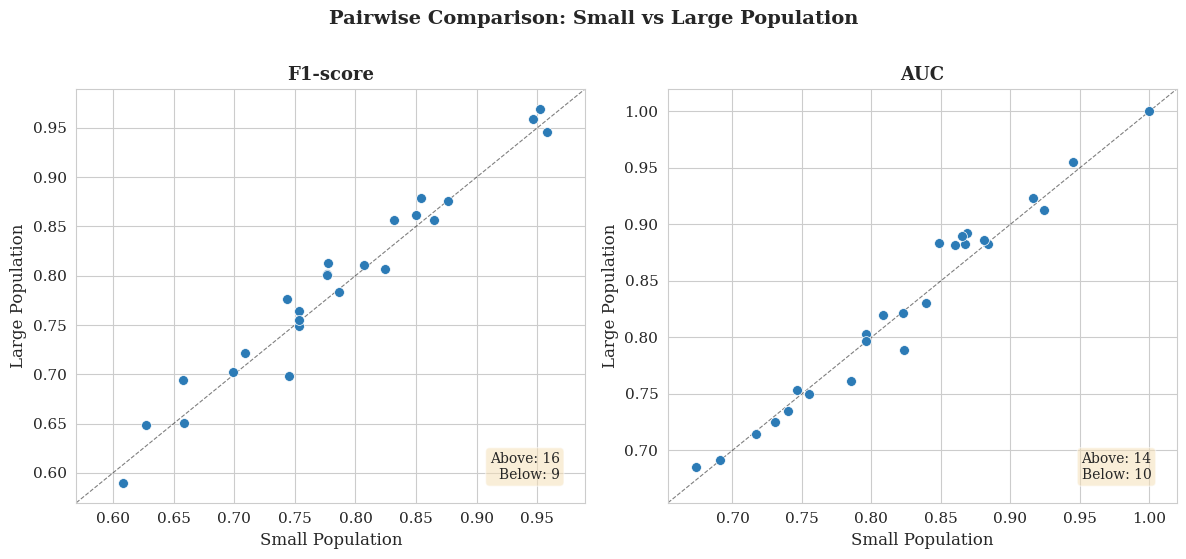

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    # 对角线
    mn = min(small_vals.min(), large_vals.min()) - 0.02
    mx = max(small_vals.max(), large_vals.max()) + 0.02
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8, alpha=0.5)
    # 散点
    ax.scatter(small_vals, large_vals, c='#2c7bb6', s=50, edgecolors='white', linewidth=0.5, zorder=5)
    ax.set_xlabel('Small Population', fontsize=12)
    ax.set_ylabel('Large Population', fontsize=12)
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

    # 统计优于/劣于对角线的比例
    above = np.sum(large_vals > small_vals)
    below = np.sum(large_vals < small_vals)
    ax.text(0.95, 0.05, f'Above: {above}\nBelow: {below}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Pairwise Comparison: Small vs Large Population', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2. 差值柱状图 (Paired Difference Bar)
每个数据集一条柱，Large − Small 的差值，正值表示Large更好

C:\Users\zsc\AppData\Local\Temp\ipykernel_8428\2001602858.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=8)


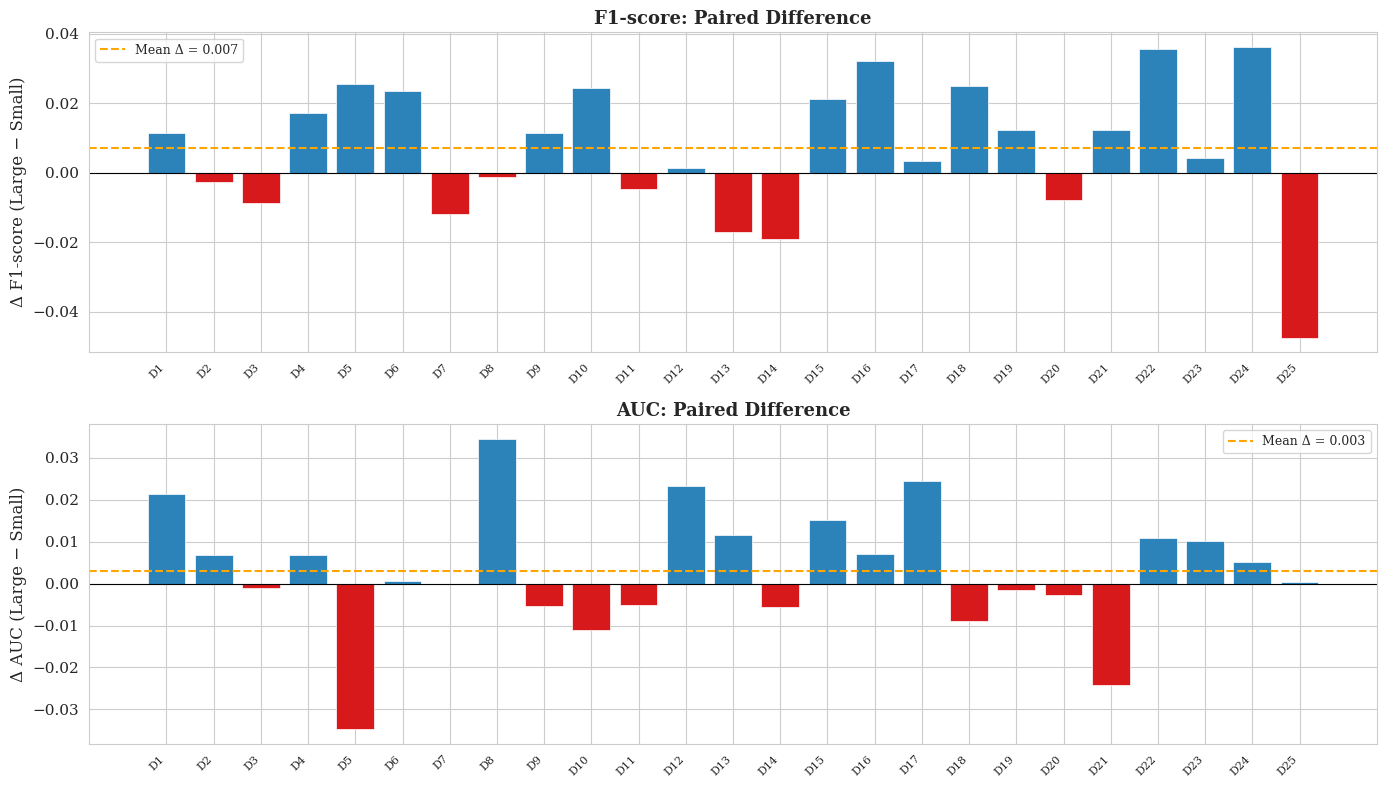

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    diff = large_vals - small_vals
    colors = ['#d7191c' if d < 0 else '#2b83ba' for d in diff]
    bars = ax.bar(datasets, diff, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_ylabel(f'Δ {metric} (Large − Small)', fontsize=12)
    ax.set_title(f'{metric}: Paired Difference', fontsize=13, fontweight='bold')
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=8)
    # 标注均值
    mean_diff = np.mean(diff)
    ax.axhline(y=mean_diff, color='orange', linestyle='--', linewidth=1.5, label=f'Mean Δ = {mean_diff:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. 箱线图 (Box Plot) — 科研论文最常用
展示所有数据集30次运行的分布对比

C:\Users\zsc\AppData\Local\Temp\ipykernel_8428\2245899573.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=7)
C:\Users\zsc\AppData\Local\Temp\ipykernel_8428\2245899573.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=7)


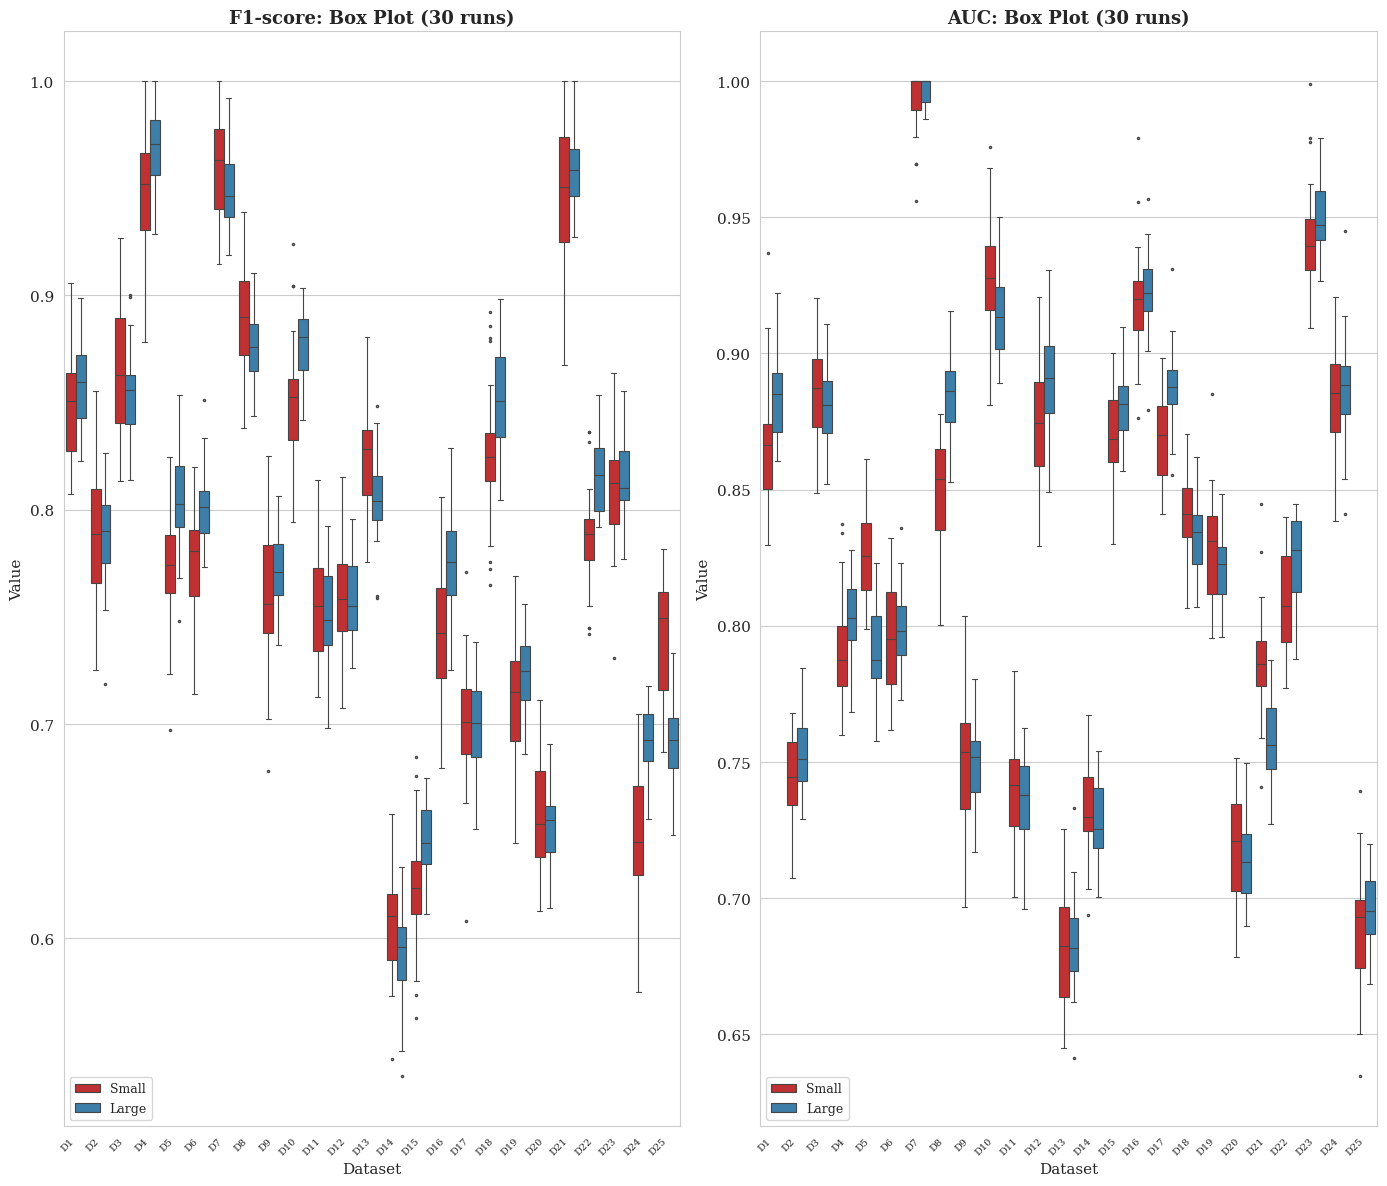

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

for ax, metric in [(axes[0], 'F1-score'), (axes[1], 'AUC')]:
    # Melt数据
    plot_df = df_box.melt(id_vars=['Dataset', 'Population'], value_vars=[metric],
                          var_name='Metric', value_name='Value')
    sns.boxplot(data=plot_df, x='Dataset', y='Value', hue='Population',
                palette={'Small': '#d7191c', 'Large': '#2b83ba'},
                fliersize=1.5, linewidth=0.8, ax=ax)
    ax.set_title(f'{metric}: Box Plot (30 runs)', fontsize=13, fontweight='bold')
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

## 4. 带误差棒的均值柱状图 (Bar with Error Bar)
横轴25个数据集，两组柱紧邻便于对比

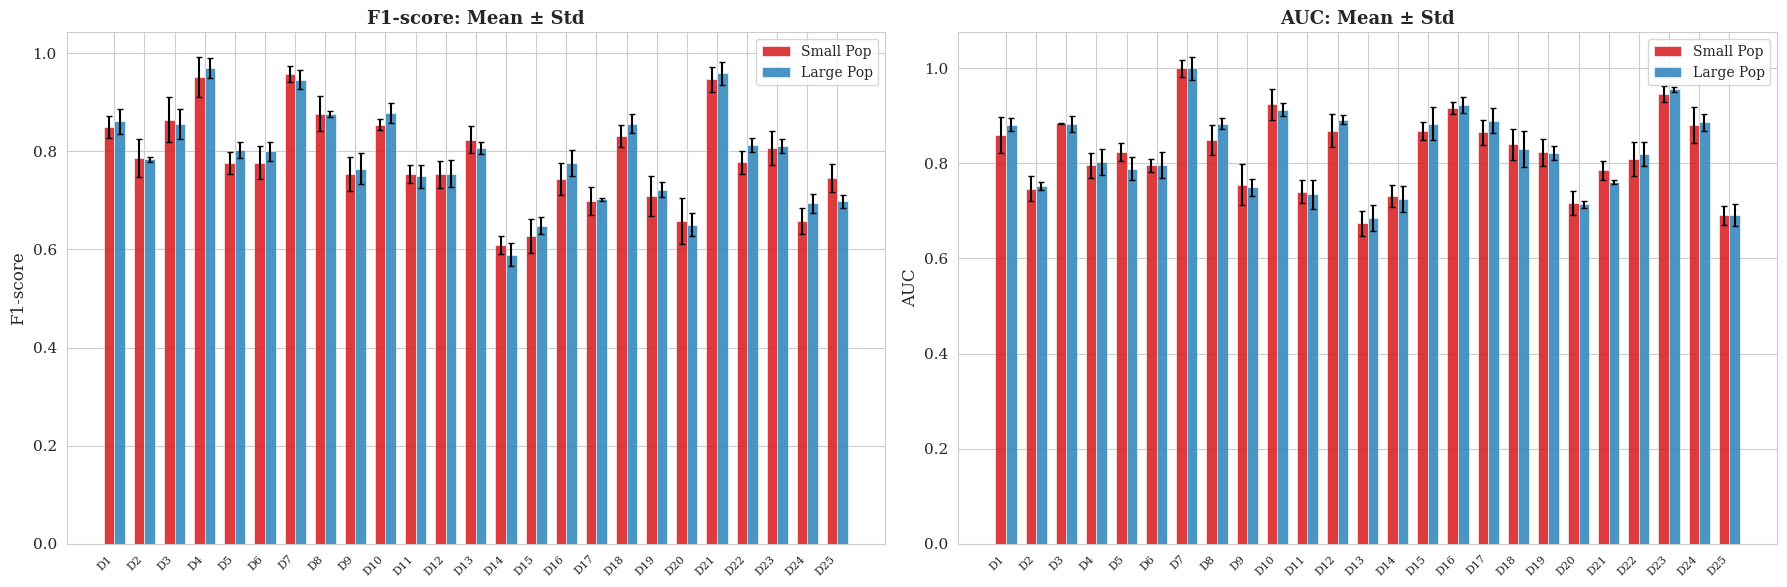

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(n)
width = 0.35

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    # 模拟标准差
    small_std = np.abs(np.random.normal(0.03, 0.01, n))
    large_std = np.abs(np.random.normal(0.02, 0.008, n))

    ax.bar(x - width/2, small_vals, width, yerr=small_std,
           color='#d7191c', alpha=0.85, capsize=2, label='Small Pop', edgecolor='white', linewidth=0.5)
    ax.bar(x + width/2, large_vals, width, yerr=large_std,
           color='#2b83ba', alpha=0.85, capsize=2, label='Large Pop', edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric}: Mean ± Std', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 5. 森林图 / 点估计 + 置信区间 (Forest Plot)
适合展示每个数据集上Large vs Small的效应量及置信区间

ValueError: ['#d7191c', '#d7191c', '#d7191c', '#d7191c', '#d7191c', '#d7191c', '#d7191c', '#d7191c', '#d7191c', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba', '#2b83ba'] is not a valid value for color

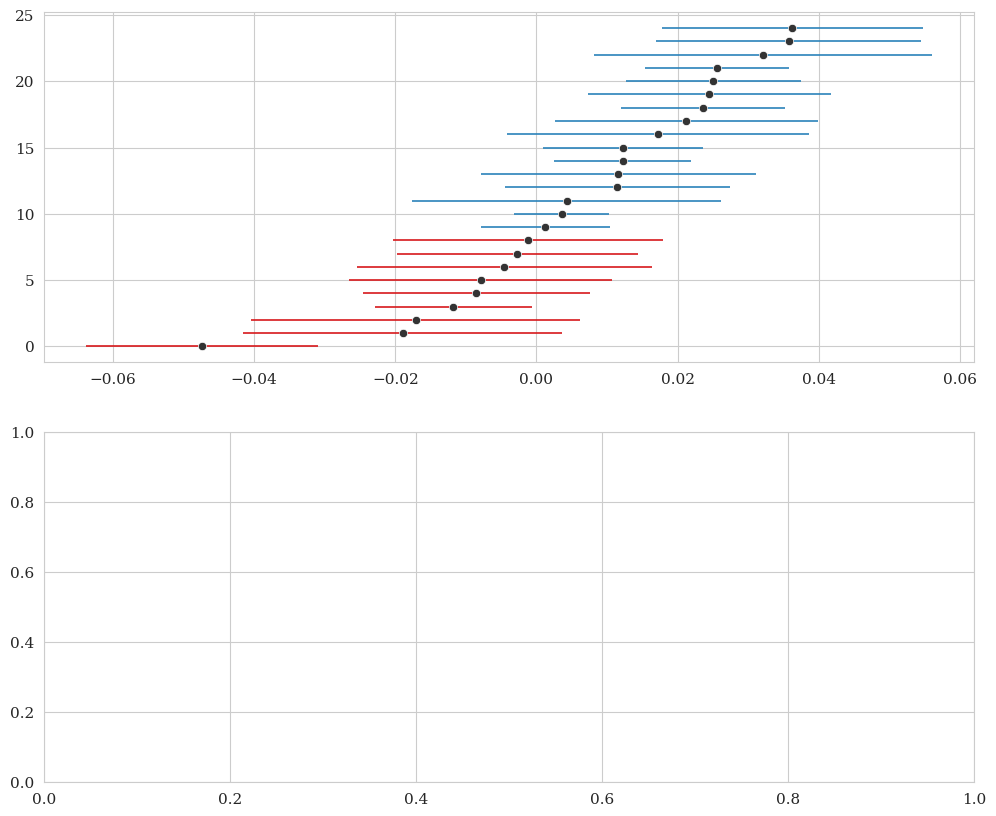

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    diff = large_vals - small_vals
    # 模拟置信区间
    ci = np.abs(np.random.normal(0.015, 0.005, n))
    # 按差值排序
    order = np.argsort(diff)
    y_pos = np.arange(n)

    colors = ['#d7191c' if diff[i] < 0 else '#2b83ba' for i in order]
    ax.errorbar(x=diff[order], y=y_pos, xerr=ci[order], fmt='o',
                color='#333333', ecolor=colors, capsize=3, markersize=6,
                elinewidth=1.2, markeredgecolor='white', markeredgewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([datasets[i] for i in order], fontsize=9)
    ax.set_xlabel(f'Δ {metric} (Large − Small)', fontsize=12)
    ax.set_title(f'{metric}: Forest Plot (95% CI)', fontsize=13, fontweight='bold')
    # 总体均值
    overall = np.mean(diff)
    ax.axvline(x=overall, color='orange', linestyle='-', linewidth=2, label=f'Overall Δ = {overall:.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. 小提琴图 (Violin Plot)
比箱线图更丰富地展示分布形态

C:\Users\zsc\AppData\Local\Temp\ipykernel_8428\3945964792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_box, x='Population', y=metric, order=plot_order,
C:\Users\zsc\AppData\Local\Temp\ipykernel_8428\3945964792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_box, x='Population', y=metric, order=plot_order,


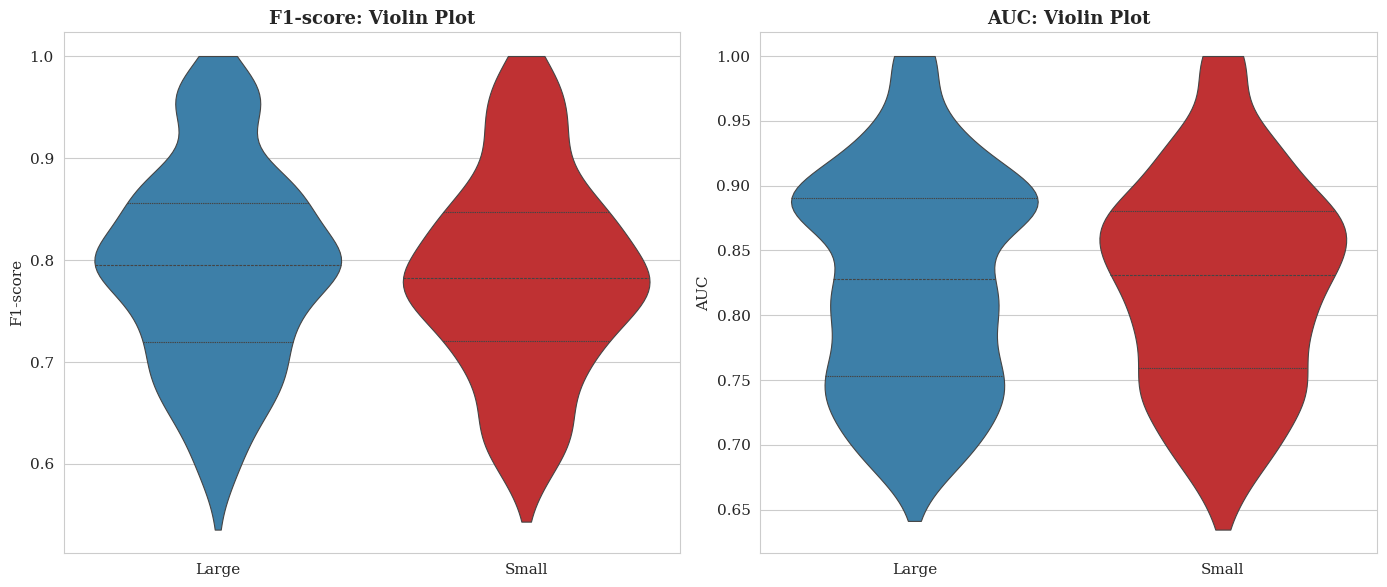

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_order = ['Large', 'Small']  # 统一显示顺序

for ax, metric in [(axes[0], 'F1-score'), (axes[1], 'AUC')]:
    sns.violinplot(data=df_box, x='Population', y=metric, order=plot_order,
                   palette={'Small': '#d7191c', 'Large': '#2b83ba'},
                   inner='quartile', cut=0, linewidth=0.8, ax=ax)
    ax.set_title(f'{metric}: Violin Plot', fontsize=13, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 7. 平行坐标图 (Parallel Coordinates) — 每个数据集一条线
直观展示从Small到Large的变化趋势

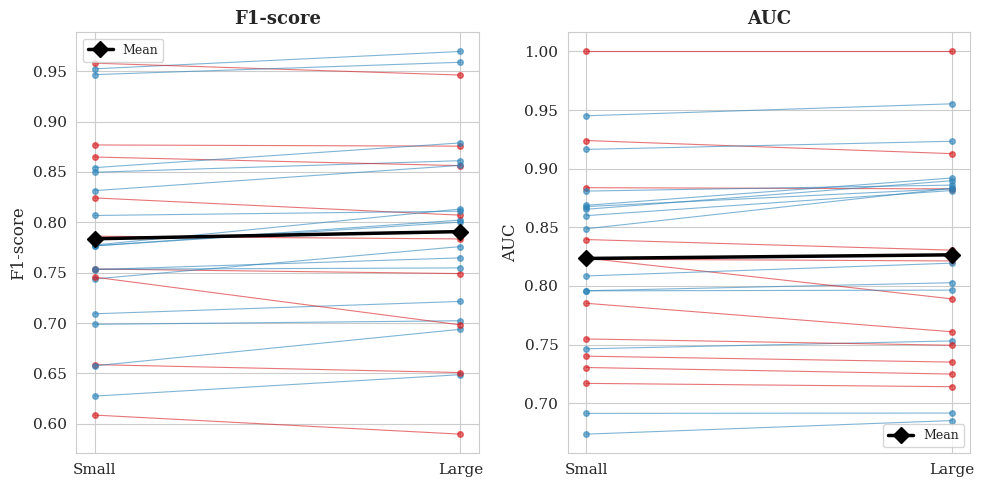

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    for i in range(n):
        ax.plot([0, 1], [small_vals[i], large_vals[i]],
                'o-', markersize=4, linewidth=0.8, alpha=0.6,
                color='#2b83ba' if large_vals[i] > small_vals[i] else '#d7191c')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Small', 'Large'])
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    # 均值线
    ax.plot([0, 1], [np.mean(small_vals), np.mean(large_vals)],
            'D-', color='black', linewidth=2.5, markersize=8, label='Mean', zorder=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. 分类性能 + 时间 联合气泡图 (Bubble Chart)
x=性能, y=时间, 气泡大小=稳定性，每个点=一个数据集

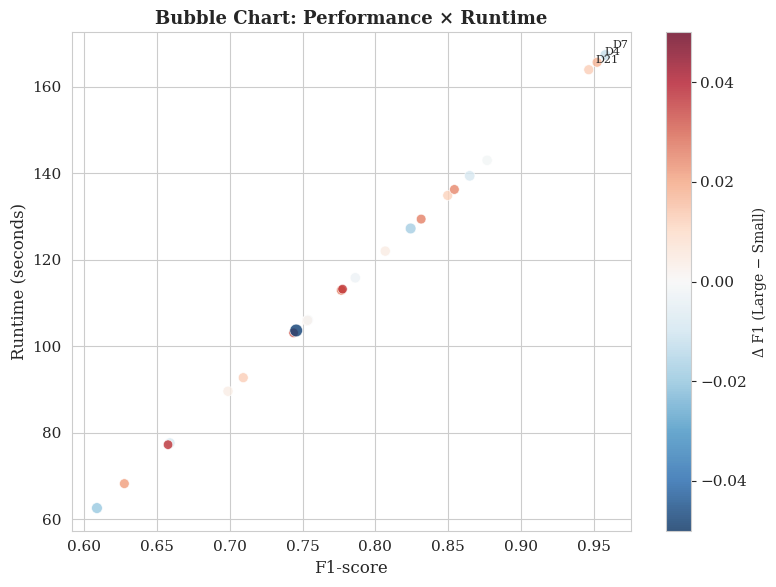

In [9]:
# 模拟时间数据
np.random.seed(42)
small_time = np.random.normal(120, 30, n)
large_time = np.random.normal(40, 10, n)
small_std = np.abs(np.random.normal(0.03, 0.01, n))
large_std = np.abs(np.random.normal(0.02, 0.008, n))

fig, ax = plt.subplots(figsize=(8, 6))

# 稳定性 = -log(std)，越大越稳定
stability = -np.log(small_std + 1e-6) * 15

scatter = ax.scatter(small_f1, small_time, s=stability, c=large_f1 - small_f1,
                     cmap='RdBu_r', edgecolors='white', linewidth=0.5,
                     vmin=-0.05, vmax=0.05, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Δ F1 (Large − Small)', fontsize=10)

ax.set_xlabel('F1-score', fontsize=12)
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Bubble Chart: Performance × Runtime', fontsize=13, fontweight='bold')

# 标注几个极端点
extreme_idx = np.argsort(small_time)[-3:]
for i in extreme_idx:
    ax.annotate(datasets[i], (small_f1[i], small_time[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

## 9. 热力图 (Heatmap)
25个数据集 × 性能差值，颜色深浅代表差异大小

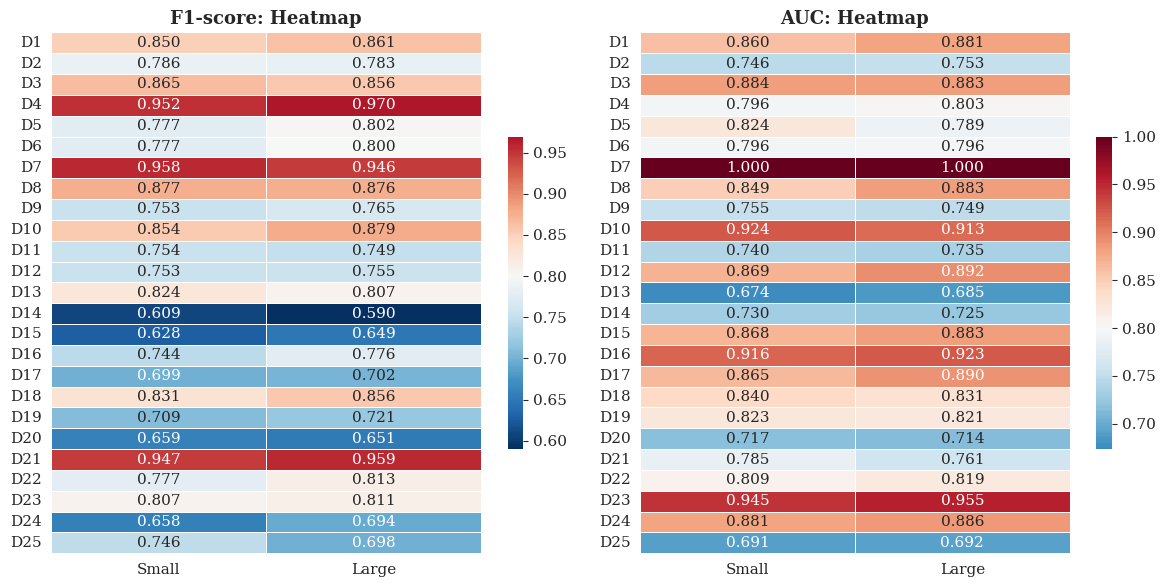

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, metric, small_vals, large_vals in [
    (axes[0], 'F1-score', small_f1, large_f1),
    (axes[1], 'AUC', small_auc, large_auc)
]:
    # 构建对比矩阵
    comparison = np.vstack([small_vals, large_vals]).T
    sns.heatmap(comparison, annot=True, fmt='.3f', cmap='RdBu_r',
                xticklabels=['Small', 'Large'], yticklabels=datasets,
                center=0.8, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.6})
    ax.set_title(f'{metric}: Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 总结与推荐

| 图表 | 适用场景 | 科研常用度 |
|------|---------|----------|
| **配对散点图 + 对角线** | 展示两个方法在各数据集上的相对表现 | ⭐⭐⭐ |
| **差值柱状图** | 直观展示每个数据集的差异方向 | ⭐⭐⭐ |
| **箱线图** | 展示多次运行的分布对比 | ⭐⭐⭐⭐⭐ |
| **带误差棒的柱状图** | 紧凑的均值对比 | ⭐⭐⭐⭐ |
| **森林图** | 展示效应量和置信区间 | ⭐⭐ |
| **小提琴图** | 箱线图的美化替代 | ⭐⭐⭐⭐ |
| **平行坐标图** | 连接线展示变化趋势 | ⭐⭐ |
| **气泡图** | 性能×时间联合对比 | ⭐⭐ |
| **热力图** | 表格化数值对比 | ⭐⭐⭐ |

> **推荐**：箱线图或小提琴图 + 配对差值柱状图组合使用，前者看整体分布，后者看逐数据集细节。